# 10: Visibility Prediction Scan

## Objetivo
Modelar numericamente a visibilidade $V(\tau) = \exp(-\gamma \tau / 2)$ comparando dois regimes de escalonamento para o coeficiente de amortecimento $\gamma$.

**Tag Epistemológica: PREVISÃO**

> [!WARNING]
> Este notebook é uma exploração numérica de hipóteses de trabalho. Os resultados aqui apresentados são PREVISÕES e não constituem validação experimental nem derivações do núcleo (core) do repositório. O regime $N^2$ é tratado aqui como uma assinatura fenomenológica a ser investigada.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definir tau
tau = np.linspace(0, 10, 1000)

# Grade de N
N_values = [10, 20, 40, 60, 80, 100]

# Constantes simples (escolhidas para comparabilidade em N pequeno)
a = 0.05
b = 0.005

def visibility(tau, gamma):
    return np.exp(-gamma * tau / 2)

# Dicionários para armazenar resultados
results_A = {}
results_B = {}

for N in N_values:
    gamma_A = a * N
    gamma_B = b * (N**2)
    results_A[N] = visibility(tau, gamma_A)
    results_B[N] = visibility(tau, gamma_B)

print(f"Parâmetros: a={a}, b={b}")
print(f"N_values: {N_values}")


Parâmetros: a=0.05, b=0.005
N_values: [10, 20, 40, 60, 80, 100]


<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\g'
C:\Users\cr_bn\AppData\Local\Temp\ipykernel_12056\1703476595.py:7: SyntaxWarning: invalid escape sequence '\g'
  plt.title('Regime A: $\gamma = aN$')
C:\Users\cr_bn\AppData\Local\Temp\ipykernel_12056\1703476595.py:17: SyntaxWarning: invalid escape sequence '\g'
  plt.title('Regime B: $\gamma = bN^2$')


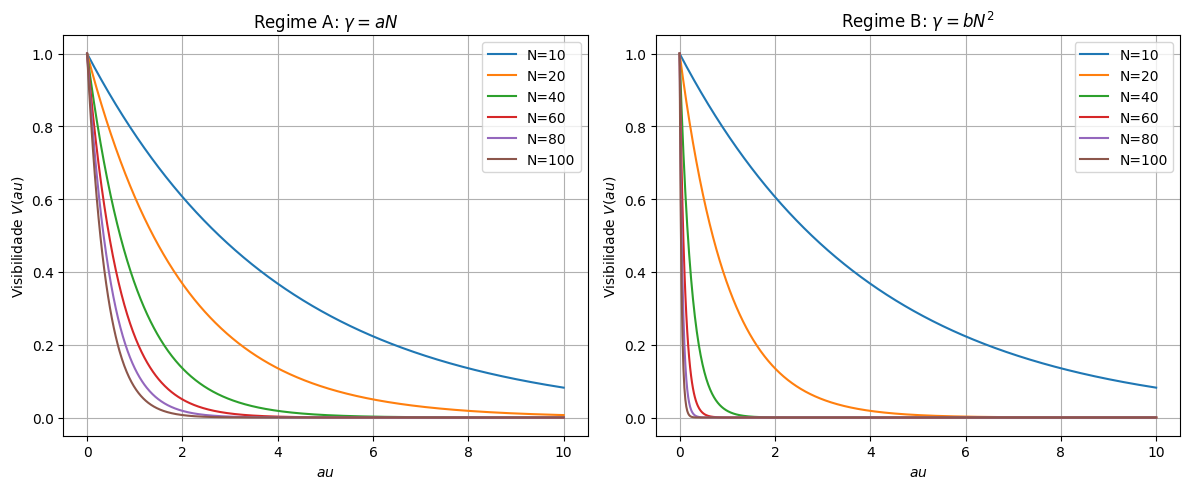

In [2]:
plt.figure(figsize=(12, 5))

# Plot Regime A
plt.subplot(1, 2, 1)
for N in N_values:
    plt.plot(tau, results_A[N], label=f'N={N}')
plt.title('Regime A: $\gamma = aN$')
plt.xlabel('$\tau$')
plt.ylabel('Visibilidade $V(\tau)$')
plt.grid(True)
plt.legend()

# Plot Regime B
plt.subplot(1, 2, 2)
for N in N_values:
    plt.plot(tau, results_B[N], label=f'N={N}')
plt.title('Regime B: $\gamma = bN^2$')
plt.xlabel('$\tau$')
plt.ylabel('Visibilidade $V(\tau)$')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [3]:
threshold = 0.1

def find_critical_tau(tau, v, thresh):
    indices = np.where(v < thresh)[0]
    if len(indices) > 0:
        return tau[indices[0]]
    return None

print(f"{'N':>4} | {'Regime A (tau_c)':>15} | {'Regime B (tau_c)':>15}")
print("-" * 40)

summary_table = []
for N in N_values:
    tau_A = find_critical_tau(tau, results_A[N], threshold)
    tau_B = find_critical_tau(tau, results_B[N], threshold)
    summary_table.append((N, tau_A, tau_B))
    t_A_str = f"{tau_A:.4f}" if tau_A is not None else "> max(tau)"
    t_B_str = f"{tau_B:.4f}" if tau_B is not None else "> max(tau)"
    print(f"{N:4d} | {t_A_str:>15} | {t_B_str:>15}")


   N | Regime A (tau_c) | Regime B (tau_c)
----------------------------------------
  10 |          9.2192 |          9.2192
  20 |          4.6146 |          2.3123
  40 |          2.3123 |          0.5806
  60 |          1.5415 |          0.2603
  80 |          1.1612 |          0.1502
 100 |          0.9309 |          0.1001


## Conclusões de Previsão

Registros:
1. O regime quadrático ($N^2$) apresenta uma queda de visibilidade significativamente mais rápida para valores crescentes de $N$.
2. A diferença nas escalas de tempo de decaimento constitui uma **assinatura de previsão** que pode ser usada para distinguir modelos em fases posteriores.
3. **IMPORTANTE**: Este exercício é puramente numérico e não constitui validação experimental do claim mínimo.
